# Extended Kalman Filter

This notebook demonstrates a **1D Extended Kalman filter** by introducing nonlinearities on the underlying dynamical model.

## 1. Model overview

The real behavior of the system is now modeled as an accelerated moving particle
with position/velocity nonlinearities driven by random jerk.

Also in this case, the state consists of position $x$, velocity $v$ and
acceleration $a$. The true dynamics of the point mass is assumed to be described
by the state equations

$$
\begin{bmatrix} x_{k+1} \\ v_{k+1} \\ a_{k+1} \end{bmatrix} = 
    \underbrace{
        \begin{bmatrix} 
            x_k + dt v_k + \frac{1}{2}dt^2a_k \\
            v_k + dt a_k \\
            a_k + dt \left(-\alpha \sin(x_k) - \beta v_k^2 \text{sgn}(v_k) \right)
        \end{bmatrix}}_{f(\cdot)}
        + \mathsf{w}_k
$$

with process noise $\mathsf{w}_k\sim\mathcal{N}(0,Q)$ where

$$
Q = \sigma_j^2 \begin{bmatrix} \tfrac{dt^5}{20} & \tfrac{dt^4}{8} & \tfrac{dt^3}{6} \\ \tfrac{dt^4}{8}  & \tfrac{dt^3}{3} & \tfrac{dt^2}{2} \\ \tfrac{dt^3}{6}  & \tfrac{dt^2}{2} & dt \end{bmatrix}.
$$

Here:
* $\alpha$ can model a nonlinear position-dependent restoring effect,
* $\beta v^2 \text{sgn}(v)$ is a nonlinear drag term.

Note that for $\alpha=\beta=0$ we fall back to the Linear model hence non-linear strenght can be analyzed.

Finally, we assume also a non-linear measurement range-like model:
$$
y^{(pos)}_k = \underbrace{\sqrt{x_k^2 + L^2}}_{h(\cdot)} + \mathsf{v}_k,\quad 
$$

with known offset $L$ where $\mathsf{v}_k\sim\mathcal{N}(0,R), R=\sigma_{\mathsf{v}}^2$.

## 2. Imports and setup

In [57]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from linear_and_nonlinear_kf.utils import simulate_nonlinear_model  # used to simulate motion and measurements

## 2. EKF model

For the EKF, we need a linearized model (Jacobians). For the process we have




$$
F_k = \left.\frac{\partial f}{\partial \mathsf{x}}\right|_{\hat{\mathsf{x}}_{k|k}}
    =   \left.\begin{bmatrix}
            1 & dt & \frac{1}{2}dt^2 \\
            0 & 1 & dt \\
            -\alpha dt \cos(x_k) & -2 \beta dt |v_k| & 1 
        \end{bmatrix}\right|_{\hat{\mathsf{x}}_{k|k}}
$$

where $\mathsf{x}$ denotes the entire state vector. For the measurement we have

$$
H_k = \left.\frac{\partial h}{\partial \mathsf{x}}\right|_{\hat{\mathsf{x}}_{k+1|k}}
    = \left.\begin{bmatrix} \frac{x_k}{\sqrt{x_k^2 + L^2}} & 0 & 0 \end{bmatrix}\right|_{\hat{\mathsf{x}}_{k+1|k}}
$$


In [58]:
def extended_kalman_filter(
    y: np.ndarray,
    dt: float,
    x0: np.ndarray,
    P0: np.ndarray,
    sigma_j: float,
    sigma_y: float,
    alpha: float = 0.0,
    beta: float = 0.0,
    L: float = 1.0,
    C: float = 0.0
):
    """
    Extended Kalman Filter for the nonlinear 1D motion model with state

        x = [position, velocity, acceleration]^T

    Process model:
        p_{k+1} = p_k + dt*v_k + 0.5*dt^2*a_k
        v_{k+1} = v_k + dt*a_k
        a_{k+1} = a_k + dt*(-alpha*sin(p_k) - beta*v_k*abs(v_k)) + w_k

    Nonlinear measurement model:
        y_k = sqrt(p_k^2 + L^2) + C*p_k + v_k^m

    where
        w_k ~ N(0, Q)
        v_k^m ~ N(0, R)

    Args:
        y (np.ndarray):
            Array of scalar measurements.
        dt (float):
            Time step.
        x0 (np.ndarray):
            Initial state [position, velocity, acceleration].
        P0 (np.ndarray):
            Initial 3x3 covariance matrix.
        sigma_j (float):
            Jerk-noise standard deviation used to build Q.
        sigma_y (float):
            Measurement noise standard deviation.
        alpha (float, optional):
            Nonlinear position-dependent coefficient in the process model.
        beta (float, optional):
            Nonlinear drag coefficient in the process model.
        L (float, optional):
            Sensor offset parameter in the nonlinear measurement model.
        C (float, optional):
            Sensor directional coefficient

    Returns:
        np.ndarray:
            Filtered state estimates with shape (N, 3).
        np.ndarray:
            Filtered covariance matrices with shape (N, 3, 3).
    """

    def f(x: np.ndarray) -> np.ndarray:
        """Nonlinear state transition."""
        p, v, a = x.flatten()
        return np.array([
            [p + dt * v + 0.5 * dt**2 * a],
            [v + dt * a],
            [a + dt * (-alpha * np.sin(p) - beta * v * abs(v))]
        ])

    def F_jacobian(x: np.ndarray) -> np.ndarray:
        """Jacobian of the nonlinear process model f(x)."""
        p, v, a = x.flatten()
        return np.array([
            [1.0,  dt,  0.5 * dt**2],
            [0.0,  1.0, dt],
            [-alpha * dt * np.cos(p), -2.0 * beta * dt * abs(v), 1.0]
        ])

    def h(x: np.ndarray) -> np.ndarray:
        """Nonlinear measurement model."""
        p = float(x[0, 0])
        return np.array([[np.sqrt(p**2 + L**2) + C*p]])

    def H_jacobian(x: np.ndarray) -> np.ndarray:
        """Jacobian of the nonlinear measurement model h(x)."""
        p = float(x[0, 0])
        denom = np.sqrt(p**2 + L**2)

        # Safe handling for pathological case denom == 0
        if denom < 1e-12:
            dhdp = 0.0
        else:
            dhdp = p / denom

        return np.array([[dhdp + C, 0.0, 0.0]])

    # Measurement noise covariance
    R = np.array([[sigma_y**2]])

    # Jerk-driven process noise covariance
    Q = sigma_j**2 * np.array([
        [dt**5 / 20.0, dt**4 / 8.0, dt**3 / 6.0],
        [dt**4 / 8.0,  dt**3 / 3.0, dt**2 / 2.0],
        [dt**3 / 6.0,  dt**2 / 2.0, dt]
    ])

    I = np.eye(3)
    x = x0.reshape(3, 1).astype(float)
    P = P0.astype(float).copy()

    xs = []
    Ps = []

    for yk in y:
        yk = np.array([[float(yk)]])

        # Predict
        F = F_jacobian(x)
        x_pred = f(x)
        P_pred = F @ P @ F.T + Q

        # Linearize measurement around predicted state
        H = H_jacobian(x_pred)
        y_pred = h(x_pred)

        # Innovation
        e = yk - y_pred
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)

        # Update
        x = x_pred + K @ e

        # Joseph stabilized covariance update
        P = (I - K @ H) @ P_pred @ (I - K @ H).T + K @ R @ K.T

        xs.append(x.flatten())
        Ps.append(P.copy())

    return np.array(xs), np.array(Ps)

## 3. Run simulation and filter

In [ ]:
# define the parameters
dt = 0.1
n_steps = 200
p0 = 0
v0 = 0
a0 = 0

# true values used to generate motion
sigma_j_true = 0.8
sigma_y_true = 2.0

# model parameters
alpha = 0.1
beta = 0.05
L = 1.0
C = 0

# generate the "true" motion and measurements. acceleration measurements saved just for checking
true_pos, true_vel, true_acc, y = simulate_nonlinear_model(
    n_steps, dt,
    p0, v0, a0,
    sigma_j_true, sigma_y_true,
    alpha, beta, L, C,
    seed=42
)

# defined the filter noise parameters
# Currently equal to the true ones -> This is the best we can do!!!
sigma_a_filter = 0.8
sigma_y_filter = 2.0

# initialize the filter: state estimate and error cov matrix
x0 = np.array([0.0, 0.0, 0.0])
# x0 = 0.000001 * np.random.rand(3)  # try with small perturbation
# x0 = np.random.rand(3)  # try with larger perturbation
# print(x0)
P0 = np.diag([10.0**2, 10.0**2, 5.0**2])

# run the filter
xs, Ps = extended_kalman_filter(
    y, dt, x0, P0, sigma_a_filter, sigma_y_filter, alpha, beta, L, C
)

# extract the results
est_pos = xs[:, 0]
est_vel = xs[:, 1]
est_acc = xs[:, 2]
t = np.arange(n_steps) * dt
sigma_pos = np.sqrt(Ps[:, 0, 0])
sigma_vel = np.sqrt(Ps[:, 1, 1])
sigma_acc = np.sqrt(Ps[:, 2, 2])

# some MSE computations
mse_pos = np.mean((true_pos - est_pos)**2)
mse_vel = np.mean((true_vel - est_vel)**2)
mse_acc = np.mean((true_acc - est_acc)**2)

print(f"Position MSE: {mse_pos:.4f}")
print(f"Velocity MSE: {mse_vel:.4f}")
print(f"Acceleration MSE: {mse_acc:.4f}")

# compute alternative estimates
est_vel_from_y = np.diff(y) / dt # naive estimates
est_vel_from_est_pos = np.diff(est_pos) / dt # from pos estimates
t_est_vel = t[1:]   # shorter by one


Position MSE: 0.7403
Velocity MSE: 1.2287
Acceleration MSE: 0.6395


## 4. Results: Position and Velocity - True vs Estimated

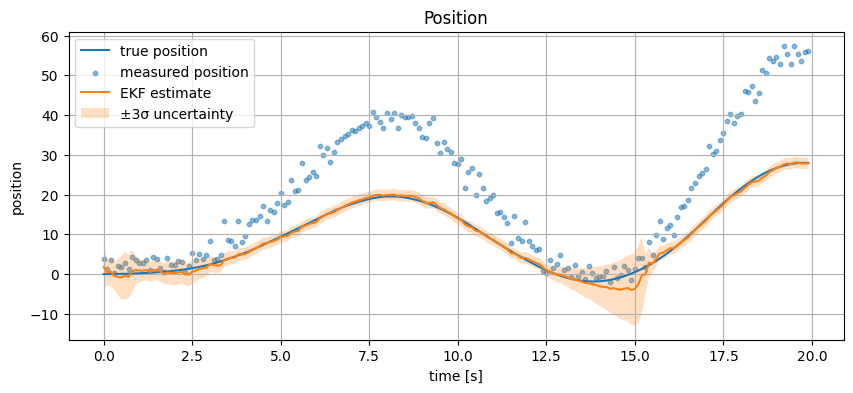

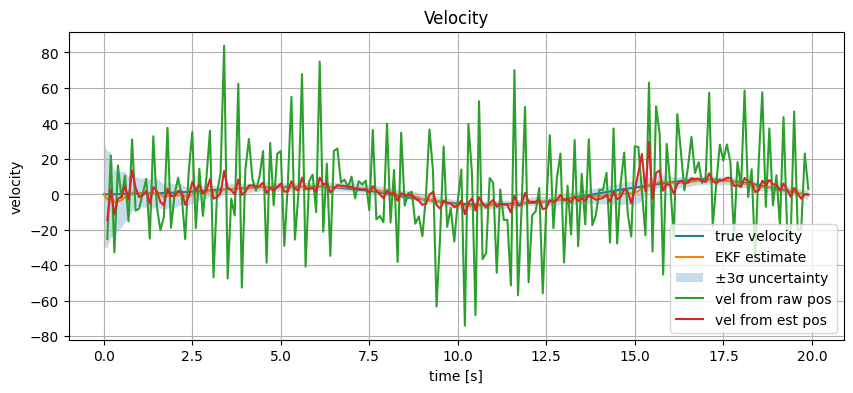

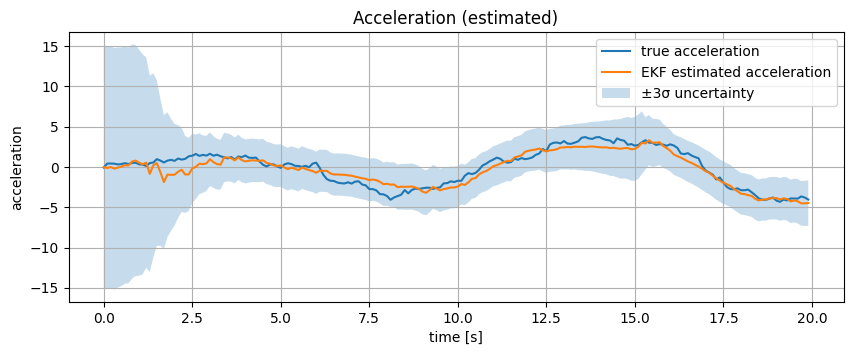

In [60]:
# plot the position
plt.figure(figsize=(10, 4))
plt.plot(t, true_pos, label='true position')
plt.scatter(t, y, s=10, alpha=0.5, label='measured position')
plt.plot(t, est_pos, label='EKF estimate')
plt.fill_between(t, est_pos - 3*sigma_pos, est_pos + 3*sigma_pos, alpha=0.25, label="±3σ uncertainty")
plt.xlabel('time [s]')
plt.ylabel('position')
plt.title('Position')
plt.legend()
plt.grid(True)
plt.show()


# plot the velocity
plt.figure(figsize=(10, 4))
plt.plot(t, true_vel, label='true velocity')
plt.plot(t, est_vel, label='EKF estimate')
plt.fill_between(t, est_vel - 3*sigma_vel, est_vel + 3*sigma_vel, alpha=0.25, label="±3σ uncertainty")
plt.plot(t_est_vel, est_vel_from_y, label="vel from raw pos")
plt.plot(t_est_vel, est_vel_from_est_pos, label="vel from est pos")
plt.xlabel('time [s]')
plt.ylabel('velocity')
plt.title('Velocity')
plt.legend()
plt.grid(True)
plt.show()

# plot the acceleration JUST FOR CHECKING
plt.figure(figsize=(10, 3.5))
plt.plot(t, true_acc, label='true acceleration')
plt.plot(t, est_acc, label='EKF estimated acceleration')
plt.fill_between(t, est_acc - 3*sigma_acc, est_acc + 3*sigma_acc, alpha=0.25, label="±3σ uncertainty")
plt.xlabel('time [s]')
plt.ylabel('acceleration')
plt.title('Acceleration (estimated)')
plt.grid(True)
plt.legend()
plt.show()

